In [1]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np



In [2]:
data=pd.read_csv(r"C:\Users\ayode\OneDrive\Desktop\Sales Forecasting\ElectroTech_Forecasting\data_cleaning\cleaned_data.csv")

In [3]:
sales_week_category = data.copy()

In [4]:
sales_week_category["Date"] = (sales_week_category["Date"]).astype('datetime64[ns]')
sales_week_category["Date"].dtype

dtype('<M8[ns]')

In [5]:
sales_week_category["Date"] = sales_week_category["Date"].dt.to_period('W').dt.to_timestamp()


In [6]:
sales_week_category

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2008-12-29,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
1,1436,Tablet,145.55,2008-12-29,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69
2,1271,Smartphone,97.82,2008-12-29,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50
3,1107,Laptop,64.00,2008-12-29,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28
4,1072,Tablet,67.83,2008-12-29,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81
...,...,...,...,...,...,...,...,...,...,...,...
136188,1361,Tablet,97.73,2020-12-28,Winter,0.953956,-0.555596,69.407099,Spec_C,High-Resolution,162
136189,1147,Tablet,173.21,2020-12-28,Winter,-0.781121,0.323828,90.737931,Spec_B,Long-Battery-Life,161
136190,1405,Accessories,154.62,2020-12-28,Winter,-0.210343,-1.055551,53.747320,Spec_A,Long-Battery-Life,182
136191,1329,Smartphone,152.00,2020-12-28,Winter,-0.492417,-1.064359,88.582224,Spec_A,Long-Battery-Life,287


In [7]:
sales_week_category=sales_week_category.groupby(['Date','Category']).sum()['Sales_Volume'].reset_index()

In [8]:
sales_week_category

,Date,Category,Sales_Volume
0,2008-12-29,Accessories,1405
1,2008-12-29,Laptop,1341
2,2008-12-29,Smartphone,1322
3,2008-12-29,Tablet,2070
4,2009-01-05,Accessories,3131
...,...,...,...
2503,2020-12-21,Tablet,7153
2504,2020-12-28,Accessories,2312
2505,2020-12-28,Laptop,2108
2506,2020-12-28,Smartphone,5723


In [9]:
sales_month_category = data.copy()
sales_month_category["Date"] = (sales_month_category["Date"]).astype('datetime64[ns]')
sales_month_category["Date"] = sales_month_category["Date"].dt.to_period('M').dt.to_timestamp()
sales_month_category=sales_month_category.groupby(['Date','Category']).sum()['Sales_Volume'].reset_index()

In [10]:
sales_month_category

,Date,Category,Sales_Volume
0,2009-01-01,Accessories,11762
1,2009-01-01,Laptop,11989
2,2009-01-01,Smartphone,12192
3,2009-01-01,Tablet,12491
4,2009-02-01,Accessories,12086
...,...,...,...
571,2020-11-01,Tablet,38059
572,2020-12-01,Accessories,30717
573,2020-12-01,Laptop,37869
574,2020-12-01,Smartphone,40987


#### Univariate Forecasting

I will begin forecasting the category by weekly sales then monthly sales to compare which of the time frame is better.
The model we will use are;
- Prophet 
- Amari



Train Test Split

In [11]:
train_data_week = {}
test_data_week= {}
for category in sales_week_category['Category'].unique():
    category_data_weekly=sales_week_category[sales_week_category['Category']==category][['Date','Sales_Volume']]
    category_data_weekly=category_data_weekly.rename(columns={'Date':'ds', 'Sales_Volume':'y'})

    train_data_week[category]=category_data_weekly[category_data_weekly['ds'].dt.year<2019]
    test_data_week[category]=category_data_weekly[category_data_weekly['ds'].dt.year>=2019]


In [12]:
train_data_week

{'Accessories':              ds      y
 0    2008-12-29   1405
 4    2009-01-05   3131
 8    2009-01-12   1323
 12   2009-01-19   2823
 16   2009-01-26   3774
 ...         ...    ...
 2072 2018-12-03   5515
 2076 2018-12-10  10280
 2080 2018-12-17  10594
 2084 2018-12-24   8534
 2088 2018-12-31   3308
 
 [523 rows x 2 columns],
 'Laptop':              ds      y
 1    2008-12-29   1341
 5    2009-01-05   2297
 9    2009-01-12   2649
 13   2009-01-19   3549
 17   2009-01-26   2625
 ...         ...    ...
 2073 2018-12-03   5314
 2077 2018-12-10   9270
 2081 2018-12-17   7577
 2085 2018-12-24  10115
 2089 2018-12-31   3990
 
 [523 rows x 2 columns],
 'Smartphone':              ds     y
 2    2008-12-29  1322
 6    2009-01-05  2483
 10   2009-01-12  2874
 14   2009-01-19  2686
 18   2009-01-26  3281
 ...         ...   ...
 2074 2018-12-03  6733
 2078 2018-12-10  7457
 2082 2018-12-17  9494
 2086 2018-12-24  9679
 2090 2018-12-31  4371
 
 [523 rows x 2 columns],
 'Tablet':              ds  

In [13]:
train_data_week['Laptop']

,ds,y
1,2008-12-29,1341
5,2009-01-05,2297
9,2009-01-12,2649
13,2009-01-19,3549
17,2009-01-26,2625
...,...,...
2073,2018-12-03,5314
2077,2018-12-10,9270
2081,2018-12-17,7577
2085,2018-12-24,10115


Visualise the weekly sales

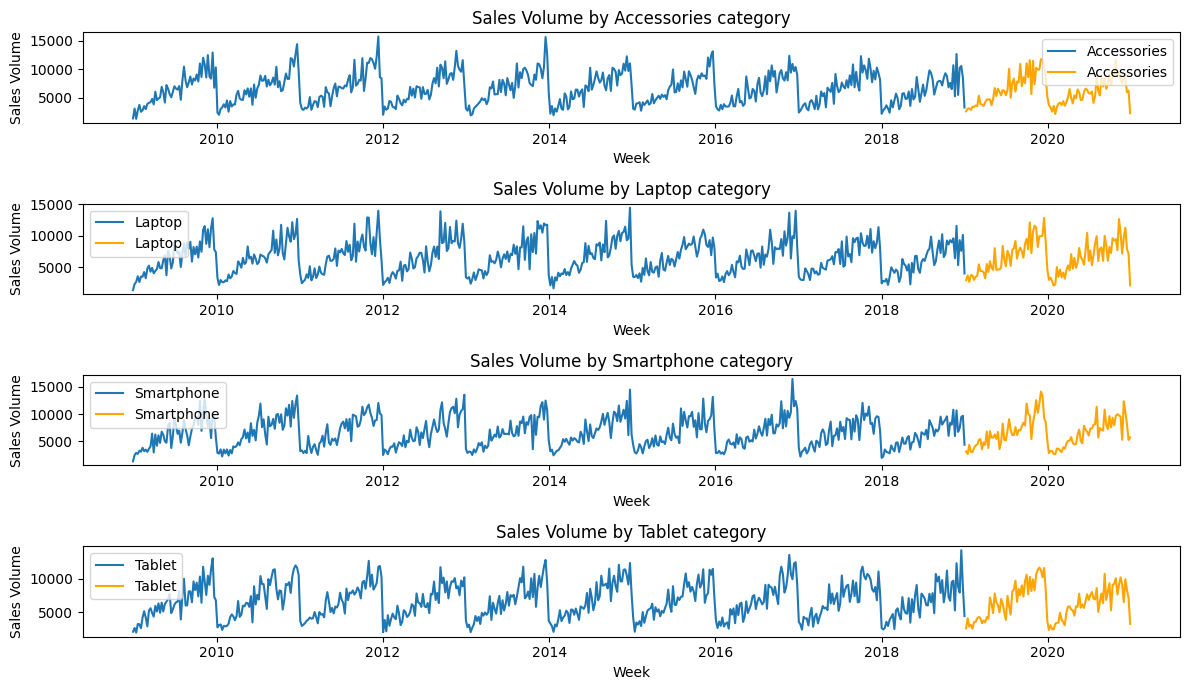

In [14]:
plt.figure(figsize=(12,7))
for i in range(4):
    category=sales_week_category['Category'].unique()[i]
    
    plt.subplot(4,1,i+1)
    plt.plot(train_data_week[category]['ds'], train_data_week[category]['y'],label=category)
    plt.plot(test_data_week[category]['ds'], test_data_week[category]['y'],label=category, color='orange')
    plt.title(f'Sales Volume by {category} category')
    plt.xlabel('Week')
    plt.ylabel('Sales Volume')
    plt.legend()
    plt.tight_layout()

plt.show()


In [15]:
#pip install prophet

In [16]:
# Prophet
from prophet import Prophet

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

c:\Users\ayode\OneDrive\Desktop\Sales Forecasting\ElectroTech_Forecasting\djenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Forecasting for Weekly

In [17]:
prophet_weekly_model=dict()
for category in sales_week_category['Category'].unique():
    model=Prophet()
    model.fit(train_data_week[category])
    prophet_weekly_model[category]=model



19:11:50 - cmdstanpy - INFO - Chain [1] start processing
19:11:51 - cmdstanpy - INFO - Chain [1] done processing
19:11:51 - cmdstanpy - INFO - Chain [1] start processing
19:11:51 - cmdstanpy - INFO - Chain [1] done processing
19:11:51 - cmdstanpy - INFO - Chain [1] start processing
19:11:51 - cmdstanpy - INFO - Chain [1] done processing
19:11:51 - cmdstanpy - INFO - Chain [1] start processing
19:11:52 - cmdstanpy - INFO - Chain [1] done processing


In [18]:
prophet_weekly_model

{'Accessories': <prophet.forecaster.Prophet at 0x17e03873cb0>,
 'Laptop': <prophet.forecaster.Prophet at 0x17e05f5d450>,
 'Smartphone': <prophet.forecaster.Prophet at 0x17e05f5d950>,
 'Tablet': <prophet.forecaster.Prophet at 0x17e05f5e5d0>}

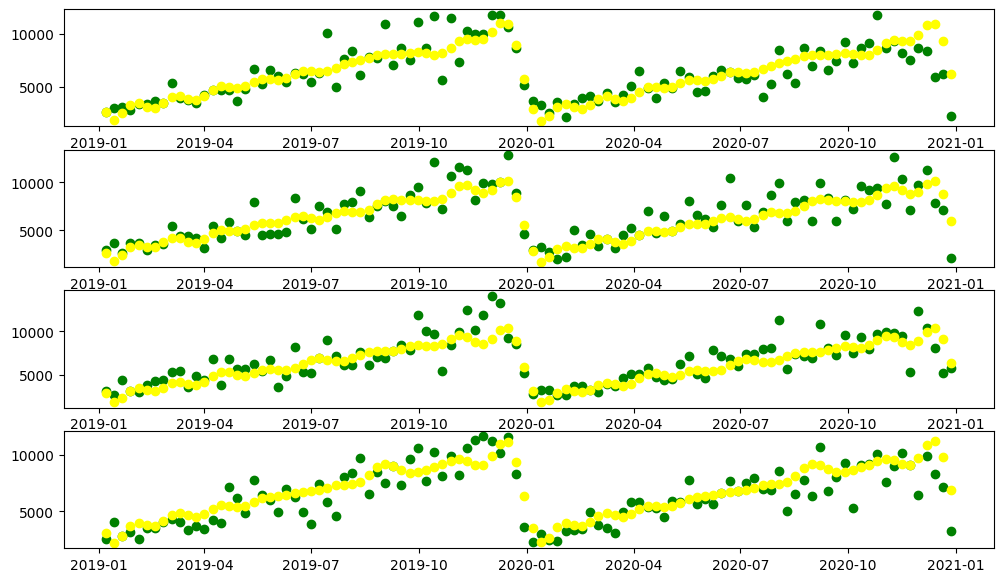

In [19]:
prophet_week_forecast = dict()
fig, ax = plt.subplots(4,1, figsize=(12, 7))
for i in range(4):
    category=sales_week_category['Category'].unique()[i]
    prophet_week_forecast[category]=prophet_weekly_model[category].predict(test_data_week[category])
    ax[i].scatter(test_data_week[category]['ds'], test_data_week[category]['y'], label='Actual', color='green')
    ax[i].scatter(prophet_week_forecast[category]['ds'], prophet_week_forecast[category]['yhat'], label='Prediction', color='yellow')
plt.show()


In [20]:
mae, mape,rmse= 0,0,0
for category in sales_week_category['Category'].unique():
    mae+=mean_absolute_error(test_data_week[category]['y'], prophet_week_forecast[category]['yhat'])
    mape+=mean_absolute_percentage_error(test_data_week[category]['y'], prophet_week_forecast[category]['yhat'])
    rmse+=root_mean_squared_error(test_data_week[category]['y'], prophet_week_forecast[category]['yhat'])

mae/=4
mape/=4
rmse/=4

print(f'MAE: {round(mae,2)}')
print(f'MAPE: {round(mape*100, 2)}%')
print(f'RMSE:{round(rmse,2)}')


MAE: 1087.98
MAPE: 18.28%
RMSE:1427.93


##### Visulaise the monthly sales

In [21]:
train_data_month = {}
test_data_month= {}
for category in sales_month_category['Category'].unique():
    category_data_monthly=sales_month_category[sales_month_category['Category']==category][['Date','Sales_Volume']]
    category_data_monthly=category_data_monthly.rename(columns={'Date':'ds', 'Sales_Volume':'y'})

    train_data_month[category]=category_data_monthly[category_data_monthly['ds'].dt.year<2019]
    test_data_month[category]=category_data_monthly[category_data_monthly['ds'].dt.year>=2019]

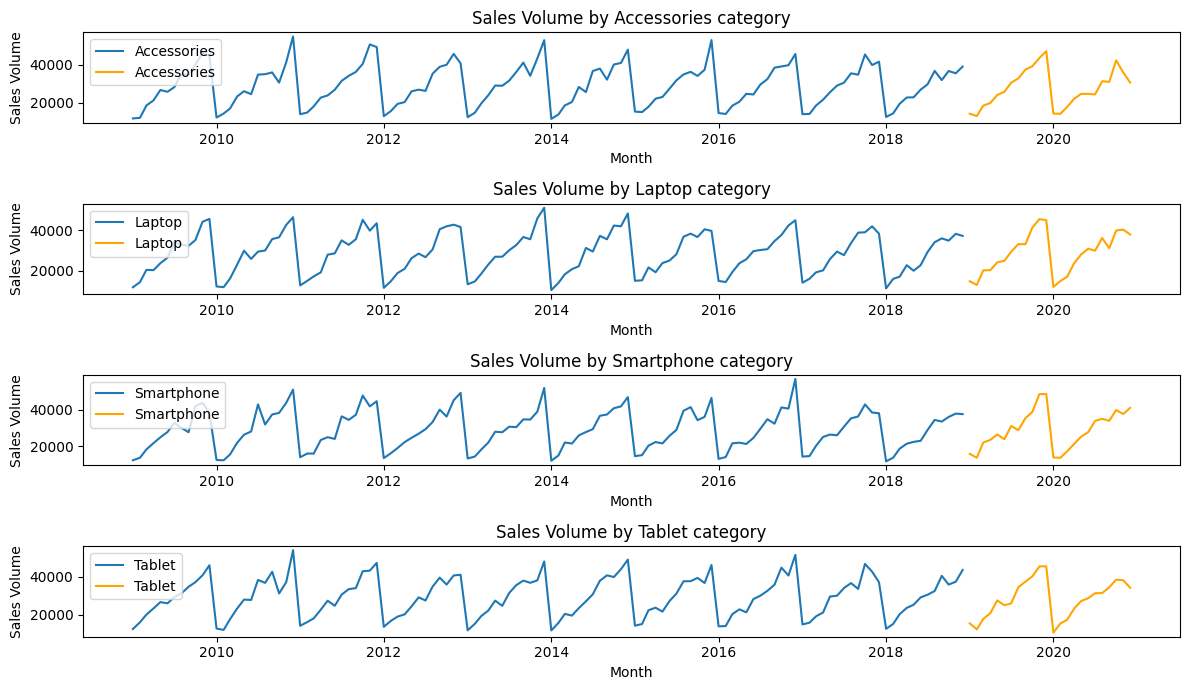

In [22]:
plt.figure(figsize=(12,7))
for i in range(4):
    category=sales_month_category['Category'].unique()[i]
    
    plt.subplot(4,1,i+1)
    plt.plot(train_data_month[category]['ds'], train_data_month[category]['y'],label=category)
    plt.plot(test_data_month[category]['ds'], test_data_month[category]['y'],label=category, color='orange')
    plt.title(f'Sales Volume by {category} category')
    plt.xlabel('Month')
    plt.ylabel('Sales Volume')
    plt.legend()
    plt.tight_layout()

plt.show()

Forecast on monthly

In [23]:
prophet_monthly_model=dict()
for category in sales_month_category['Category'].unique():
    model=Prophet()
    model.fit(train_data_month[category])
    prophet_monthly_model[category]=model

19:11:53 - cmdstanpy - INFO - Chain [1] start processing
19:11:53 - cmdstanpy - INFO - Chain [1] done processing
19:11:53 - cmdstanpy - INFO - Chain [1] start processing
19:11:53 - cmdstanpy - INFO - Chain [1] done processing
19:11:53 - cmdstanpy - INFO - Chain [1] start processing
19:11:53 - cmdstanpy - INFO - Chain [1] done processing
19:11:53 - cmdstanpy - INFO - Chain [1] start processing
19:11:53 - cmdstanpy - INFO - Chain [1] done processing


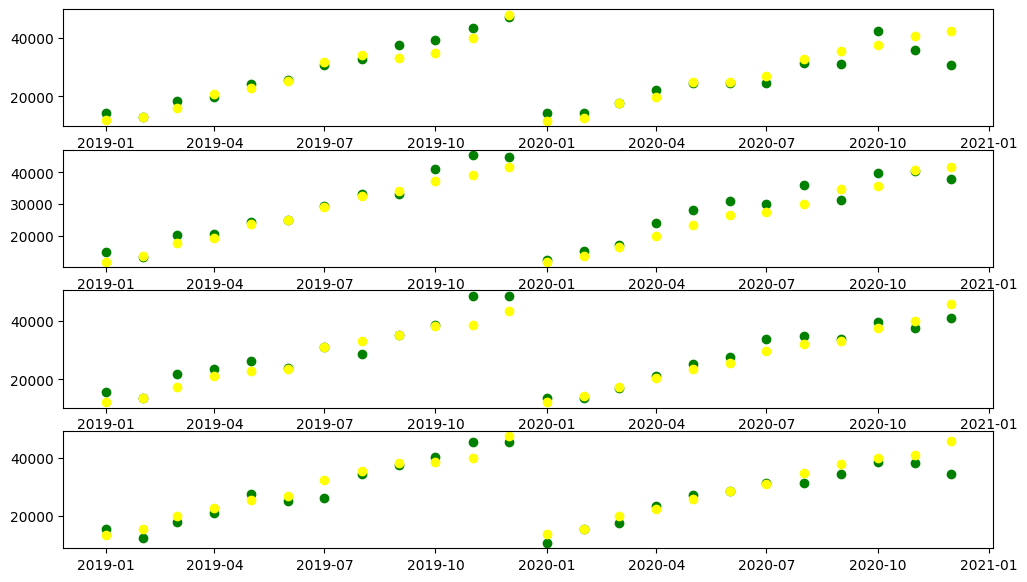

In [24]:
prophet_monthly_forecast = dict()
fig, ax = plt.subplots(4,1, figsize=(12, 7))
for i in range(4):
    category=sales_month_category['Category'].unique()[i]
    prophet_monthly_forecast[category]=prophet_monthly_model[category].predict(test_data_month[category])
    ax[i].scatter(test_data_month[category]['ds'], test_data_month[category]['y'], label='Actual', color='green')
    ax[i].scatter(prophet_monthly_forecast[category]['ds'], prophet_monthly_forecast[category]['yhat'], label='Prediction', color='yellow')
plt.show()

In [25]:
mae, mape,rmse= 0,0,0
for category in sales_month_category['Category'].unique():
    mae+=mean_absolute_error(test_data_month[category]['y'], prophet_monthly_forecast[category]['yhat'])
    mape+=mean_absolute_percentage_error(test_data_month[category]['y'], prophet_monthly_forecast[category]['yhat'])
    rmse+=root_mean_squared_error(test_data_month[category]['y'], prophet_monthly_forecast[category]['yhat'])

mae/=4
mape/=4
rmse/=4

print(f'MAE: {round(mae,2)}')
print(f'MAPE: {round(mape*100, 2)}%')
print(f'RMSE:{round(rmse,2)}')

MAE: 2487.01
MAPE: 9.0%
RMSE:3354.73


##### For Prophet Model, the monthly frequency would be selected due to lesser amount of `MAPE`

#### ARIMA MODEL

In [26]:
"""Arima_week_model = dict()

for category in sales_week_category['Category'].unique():
    # Extract data for this category
    df_category = train_data_week[train_data_week['Category'] == category].copy()
    
    # Ensure it is sorted by date
    df_category = df_category.sort_values('Date')
    
    # Extract target Series
    y = df_category['Sales_Volume']
    
    # Fit ARIMA model
    model = ARIMA(y, order=(1,1,1))
    model_fit = model.fit()
    
    # Store fitted model for this category
    Arima_week_model[category] = model_fit"""

"Arima_week_model = dict()\n\nfor category in sales_week_category['Category'].unique():\n    # Extract data for this category\n    df_category = train_data_week[train_data_week['Category'] == category].copy()\n\n    # Ensure it is sorted by date\n    df_category = df_category.sort_values('Date')\n\n    # Extract target Series\n    y = df_category['Sales_Volume']\n\n    # Fit ARIMA model\n    model = ARIMA(y, order=(1,1,1))\n    model_fit = model.fit()\n\n    # Store fitted model for this category\n    Arima_week_model[category] = model_fit"